# TIGER Challenge — Detection Track: Exploratory Data Analysis
## With S3FS Streaming (Direct from AWS, No Download Needed)

**Track:** Lymphocyte / plasma cell detection (bounding boxes)
**Dataset:** Streamed directly from `s3://tiger-training/` using anonymous S3 access via `s3fs`
**Source:** TIGER Grand Challenge (IEEE SPS GS MSP Cup 2024)

### Why this method instead of DagsHub
DagsHub's streaming mirror wasn't serving files reliably. `s3fs` talks **directly to the official
AWS S3 bucket** (`s3://tiger-training/`) with anonymous, read-only access — no third-party mirror,
no login, no API key. Files are opened as file-like objects and only the bytes you actually request
are pulled over the network.

### What this notebook does
1. Connects to `s3://tiger-training/` anonymously via `s3fs`
2. Discovers COCO JSON annotations and PNG images using `s3fs`'s native `glob`/`find` (these work
   correctly here, unlike with the DagsHub-hooked filesystem)
3. Runs **basic corrupted-file checks** (unreadable files, malformed JSON)
4. Computes dataset statistics: image counts, source breakdown, cell counts, bounding box distributions
5. Visualizes sample ROIs with bounding boxes overlaid
6. Analyzes **color/stain variability** to decide if stain normalization is needed

> **Note:** Run this in **Google Colab**. Each file is streamed on access; nothing is downloaded to disk in bulk.


## Step 0 — Setup: install & import libraries

In [ ]:
!pip install -q pycocotools s3fs fsspec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 50.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.6.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.6.0 which is incompatible.


In [ ]:
import os
import json
import re

import random
from io import BytesIO
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm.auto import tqdm

import s3fs

random.seed(42)
np.random.seed(42)


## Step 1 — Connect to S3 anonymously

`s3fs.S3FileSystem(anon=True)` gives read-only access to public buckets with no credentials.
We point it at the official `tiger-training` bucket used by the TIGER Grand Challenge.


In [ ]:
BUCKET_ROOT = "tiger-training/wsirois/roi-level-annotations"

s3 = s3fs.S3FileSystem(anon=True)

print("Connected to S3 (anonymous, read-only).")
print(f"Checking bucket root: {BUCKET_ROOT}")

try:
    top_level = s3.ls(BUCKET_ROOT)
    print(f"\n✓ Found {len(top_level)} items under {BUCKET_ROOT}:")
    for item in top_level[:30]:
        print(f"  {item}")
except Exception as e:
    print(f"Could not list {BUCKET_ROOT}: {e}")
    print("Trying the bucket root instead...")
    print(s3.ls("tiger-training"))


Connected to S3 (anonymous, read-only).
Checking bucket root: tiger-training/wsirois/roi-level-annotations

✓ Found 2 items under tiger-training/wsirois/roi-level-annotations:
  tiger-training/wsirois/roi-level-annotations/tissue-bcss
  tiger-training/wsirois/roi-level-annotations/tissue-cells


## Step 2 — Discover COCO JSON and PNG files

`s3fs` supports `glob` natively against S3, so we can search recursively without a custom crawler.


In [ ]:
print("Discovering COCO JSON files...")
all_json = s3.glob(f"{BUCKET_ROOT}/**/*.json")
print(f"Found {len(all_json)} JSON files")

print("\nDiscovering PNG image files...")
all_png = s3.glob(f"{BUCKET_ROOT}/**/*.png")
print(f"Found {len(all_png)} PNG files")

print("\nSample JSON paths:")
for p in all_json[:3]:
    print(f"  {p}")
print("\nSample PNG paths:")
for p in all_png[:3]:
    print(f"  {p}")


Discovering COCO JSON files...
Found 1 JSON files

Discovering PNG image files...
Found 4061 PNG files

Sample JSON paths:
  tiger-training/wsirois/roi-level-annotations/tissue-cells/tiger-coco.json

Sample PNG paths:
  tiger-training/wsirois/roi-level-annotations/tissue-bcss/images/TCGA-A1-A0SK-01Z-00-DX1.A44D70FA-4D96-43F4-9DD7-A61535786297_[22877, 12530, 24892, 13993].png
  tiger-training/wsirois/roi-level-annotations/tissue-bcss/images/TCGA-A1-A0SP-01Z-00-DX1.20D689C6-EFA5-4694-BE76-24475A89ACC0_[3401, 26862, 6276, 28896].png
  tiger-training/wsirois/roi-level-annotations/tissue-bcss/images/TCGA-A2-A04P-01Z-00-DX1.5B481E02-D269-4732-8FDD-6494E6EE2B71_[52125, 24261, 54392, 26004].png


## Step 3 — Identify COCO detection annotation files

Filter for JSON files that actually have the COCO annotation structure (`annotations` key).


In [ ]:
def looks_like_coco(s3_path):
    """Check if a JSON file is COCO-format by examining its structure"""
    try:
        with s3.open(s3_path, 'r') as f:
            data = json.load(f)
        if isinstance(data, dict) and 'annotations' in data:
            return True, data
        return False, data
    except Exception as e:
        return None, str(e)

coco_files = []
non_coco_files = []
broken_json_files = []

print("Validating JSON files (checking which are COCO-format)...")
for jp in tqdm(all_json, desc="Scanning JSON files"):
    is_coco, payload = looks_like_coco(jp)
    if is_coco is True:
        coco_files.append(jp)
    elif is_coco is False:
        non_coco_files.append(jp)
    else:
        broken_json_files.append((jp, payload))

print(f"\n✓ COCO-format annotation files: {len(coco_files)}")
print(f"  Other/non-COCO JSON files: {len(non_coco_files)}")
print(f"  Unreadable/broken JSON files: {len(broken_json_files)}")
if broken_json_files:
    print("\n  Broken files:")
    for jp, err in broken_json_files[:5]:
        print(f"    {jp}: {str(err)[:60]}")


Validating JSON files (checking which are COCO-format)...


Scanning JSON files:   0%|          | 0/1 [00:00<?, ?it/s]


✓ COCO-format annotation files: 1
  Other/non-COCO JSON files: 0
  Unreadable/broken JSON files: 0


## Step 4 — Basic corrupted-file checks

Verify that images referenced in each COCO JSON actually exist in the bucket and are readable.


In [ ]:
corrupted_images = []
checked_images = 0

# Build lookup of PNG files by basename
png_by_name = defaultdict(list)
for p in all_png:
    png_by_name[os.path.basename(p)].append(p)

print("Validating images referenced in COCO files...")
for jp in tqdm(coco_files, desc="Checking image references"):
    try:
        with s3.open(jp, 'r') as f:
            data = json.load(f)
    except Exception:
        continue

    for img_entry in data.get('images', []):
        fname = img_entry.get('file_name')
        checked_images += 1

        candidates = png_by_name.get(os.path.basename(fname), [])
        if not candidates:
            corrupted_images.append((jp, fname, "file not found"))
            continue

        try:
            with s3.open(candidates[0], 'rb') as f:
                img_bytes = f.read()
            img = Image.open(BytesIO(img_bytes))
            img.verify()
        except Exception as e:
            corrupted_images.append((jp, fname, f"failed to open: {str(e)[:50]}"))

print(f"\n✓ Checked {checked_images} images")
print(f"  Corrupted/missing images: {len(corrupted_images)}")
if corrupted_images:
    print("\n  Issues found:")
    for c in corrupted_images[:10]:
        print(f"    {c[1]}: {c[2]}")


Validating images referenced in COCO files...


Checking image references:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Step 5 — Aggregate dataset statistics

Load COCO data and build a comprehensive table of images and bounding boxes for analysis.


In [ ]:
records = []
bbox_records = []
bbox_xy_records = []

print("Aggregating COCO annotations...")
for jp in tqdm(coco_files, desc="Loading COCO files"):
    try:
        with s3.open(jp, 'r') as f:
            data = json.load(f)
    except Exception:
        continue

    images_by_id = {img['id']: img for img in data.get('images', [])}
    anns_by_image = defaultdict(list)

    for ann in data.get('annotations', []):
        anns_by_image[ann['image_id']].append(ann)

    for img_id, img_entry in images_by_id.items():
        fname = img_entry.get('file_name')
        width = img_entry.get('width')
        height = img_entry.get('height')
        n_cells = len(anns_by_image.get(img_id, []))

        records.append({
            'source_json': jp,
            'file_name': fname,
            'width': width,
            'height': height,
            'n_cells': n_cells,
        })

        for ann in anns_by_image.get(img_id, []):
            x, y, w, h = ann['bbox']
            bbox_records.append({
                'file_name': fname,
                'bbox_w': w,
                'bbox_h': h,
                'bbox_area': w * h,
            })
            bbox_xy_records.append({
                'file_name': fname,
                'x': x, 'y': y, 'w': w, 'h': h,
            })

df_images = pd.DataFrame(records)
df_boxes = pd.DataFrame(bbox_records)
df_boxes_xy = pd.DataFrame(bbox_xy_records)

print(f"\n✓ Total ROI images: {len(df_images)}")
print(f"✓ Total cell annotations: {len(df_boxes)}")
print(f"\nImages with 0 annotated cells: {(df_images['n_cells'] == 0).sum()} / {len(df_images)}")


Aggregating COCO annotations...


Loading COCO files:   0%|          | 0/1 [00:00<?, ?it/s]


✓ Total ROI images: 1879
✓ Total cell annotations: 30524

Images with 0 annotated cells: 740 / 1879


### Image source breakdown

In [ ]:
def infer_source(fname):
    basename = os.path.basename(fname)
    if re.match(r"TC_S\d+_P\d+", basename):
        return 'RUMC'
    if basename.startswith('TCGA'):
        return 'TCGA'
    if re.match(r"^\d+[BS]", basename):
        return 'JB'
    return 'unknown'

df_images['source'] = df_images['file_name'].apply(infer_source)
print(df_images['source'].value_counts())


source
TCGA    1744
RUMC      81
JB        54
Name: count, dtype: int64


### Image size distribution

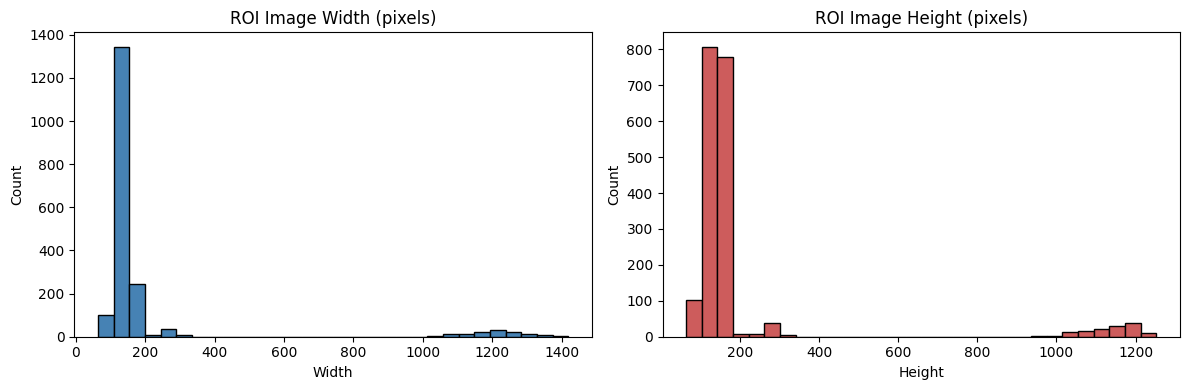

             width       height
count  1879.000000  1879.000000
mean    221.104311   215.647153
std     278.100779   258.695759
min      64.000000    64.000000
25%     137.000000   137.000000
50%     144.000000   144.000000
75%     153.000000   153.000000
max    1419.000000  1253.000000


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_images['width'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('ROI Image Width (pixels)')
axes[0].set_xlabel('Width')
axes[0].set_ylabel('Count')

axes[1].hist(df_images['height'], bins=30, color='indianred', edgecolor='black')
axes[1].set_title('ROI Image Height (pixels)')
axes[1].set_xlabel('Height')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(df_images[['width', 'height']].describe())


### Cells-per-image distribution

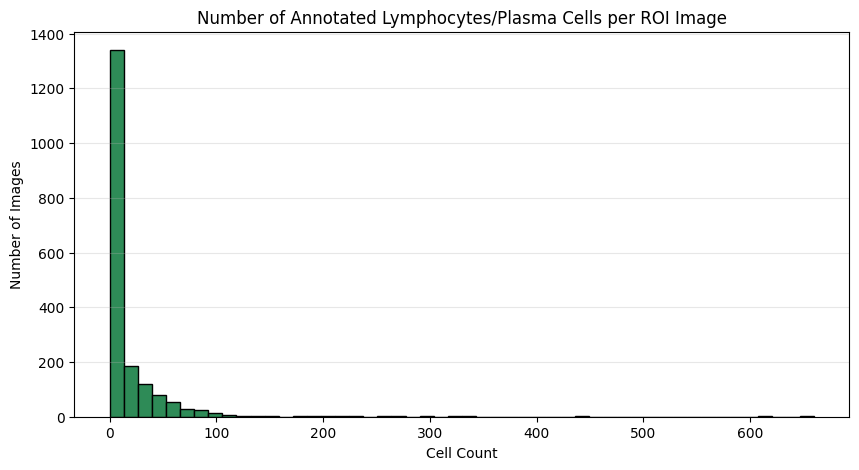

count    1879.000000
mean       16.244811
std        39.671141
min         0.000000
25%         0.000000
50%         2.000000
75%        18.000000
max       660.000000
Name: n_cells, dtype: float64


In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df_images['n_cells'], bins=50, color='seagreen', edgecolor='black')
plt.title('Number of Annotated Lymphocytes/Plasma Cells per ROI Image')
plt.xlabel('Cell Count')
plt.ylabel('Number of Images')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(df_images['n_cells'].describe())


### Bounding box size distribution

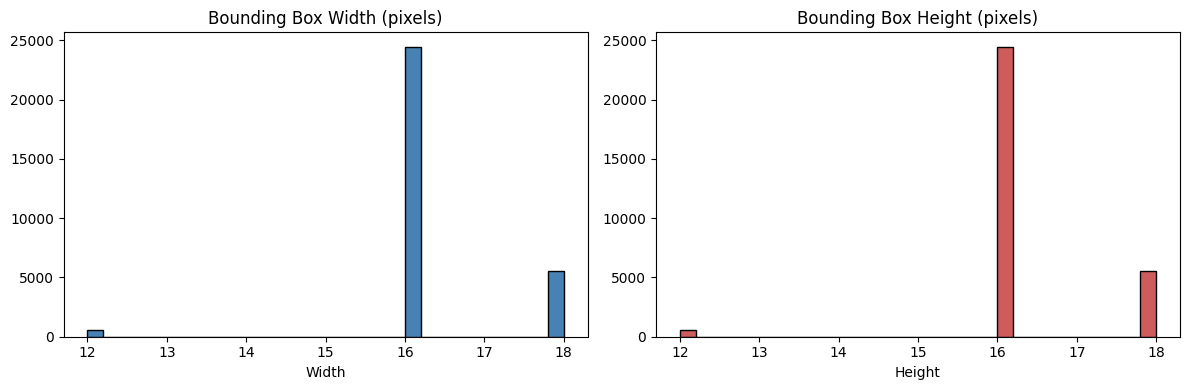

             bbox_w        bbox_h     bbox_area
count  30524.000000  30524.000000  30524.000000
mean      16.287249     16.287249    266.211506
std        0.968010      0.968010     31.047732
min       12.000000     12.000000    144.000000
25%       16.000000     16.000000    256.000000
50%       16.000000     16.000000    256.000000
75%       16.000000     16.000000    256.000000
max       18.000000     18.000000    324.000000


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_boxes['bbox_w'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Bounding Box Width (pixels)')
axes[0].set_xlabel('Width')

axes[1].hist(df_boxes['bbox_h'], bins=30, color='indianred', edgecolor='black')
axes[1].set_title('Bounding Box Height (pixels)')
axes[1].set_xlabel('Height')

plt.tight_layout()
plt.show()

print(df_boxes[['bbox_w', 'bbox_h', 'bbox_area']].describe())


## Step 6 — Visualize sample ROIs with bounding boxes

Display 6 random ROIs with their annotated cell bounding boxes overlaid.


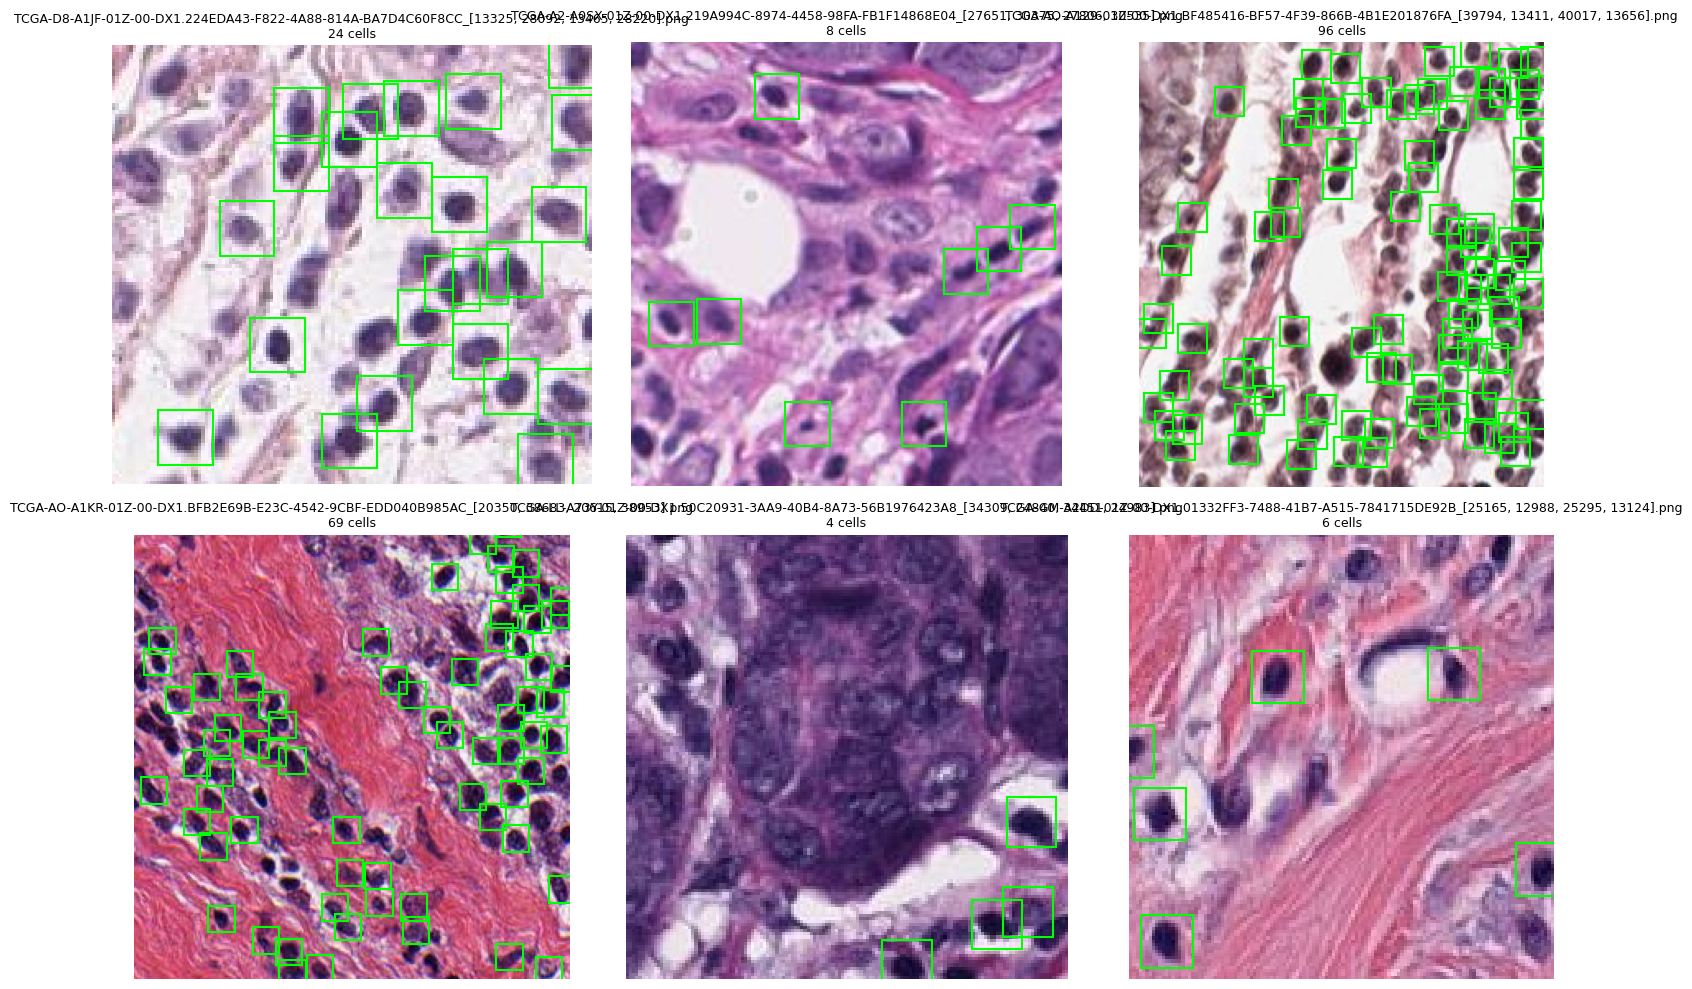

In [ ]:
def find_image_path(fname):
    candidates = png_by_name.get(os.path.basename(fname), [])
    return candidates[0] if candidates else None

annotated = df_images[df_images['n_cells'] > 0]
sample_candidates = annotated.sample(min(6, len(annotated)), random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_candidates.iterrows()):
    img_path = find_image_path(row['file_name'])
    if img_path is None:
        ax.set_title("image not found")
        ax.axis('off')
        continue

    try:
        with s3.open(img_path, 'rb') as f:
            img_bytes = f.read()
        im = Image.open(BytesIO(img_bytes)).convert('RGB')
    except Exception as e:
        ax.set_title(f"failed to load: {str(e)[:30]}")
        ax.axis('off')
        continue

    ax.imshow(im)
    ax.set_title(f"{os.path.basename(row['file_name'])}\n{row['n_cells']} cells", fontsize=9)
    ax.axis('off')

    boxes = df_boxes_xy[df_boxes_xy['file_name'] == row['file_name']]
    for _, b in boxes.iterrows():
        rect = patches.Rectangle((b['x'], b['y']), b['w'], b['h'],
                                  linewidth=1.5, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)

plt.tight_layout()
plt.show()


## Step 7 — Color/Stain variability analysis

Compute mean RGB per image across sources to assess whether stain normalization is needed for detection.


In [ ]:
def mean_rgb(img_path, max_side=256):
    """Compute mean R, G, B from a streamed S3 image"""
    try:
        with s3.open(img_path, 'rb') as f:
            img_bytes = f.read()
        im = Image.open(BytesIO(img_bytes)).convert('RGB')
        im.thumbnail((max_side, max_side))
        arr = np.asarray(im).astype(np.float32)
        return arr[..., 0].mean(), arr[..., 1].mean(), arr[..., 2].mean()
    except Exception:
        return None, None, None

color_records = []
for source in df_images['source'].unique():
    subset = df_images[df_images['source'] == source]
    subset = subset.sample(min(30, len(subset)), random_state=42)

    for _, row in tqdm(subset.iterrows(), total=len(subset), desc=f"Color: {source}"):
        img_path = find_image_path(row['file_name'])
        if img_path is None:
            continue
        r, g, b = mean_rgb(img_path)
        if r is not None:
            color_records.append({'source': source, 'R': r, 'G': g, 'B': b})

df_color = pd.DataFrame(color_records)
if len(df_color) > 0:
    print(df_color.groupby('source')[['R', 'G', 'B']].describe())


Color: TCGA:   0%|          | 0/30 [00:00<?, ?it/s]

Color: RUMC:   0%|          | 0/30 [00:00<?, ?it/s]

Color: JB:   0%|          | 0/30 [00:00<?, ?it/s]

           R                                                             \
       count        mean        std         min         25%         50%   
source                                                                    
JB      30.0  193.940094  15.280922  163.279877  183.897915  193.005882   
RUMC    30.0  217.624786  16.882717  178.537048  207.469849  216.116318   
TCGA    30.0  161.071091  23.448967  103.046524  143.667263  168.029205   

                                   G              ...                          \
               75%         max count        mean  ...         75%         max   
source                                            ...                           
JB      204.697971  224.877808  30.0  149.084656  ...  166.025967  204.440903   
RUMC    232.472939  246.908981  30.0  179.040756  ...  196.089668  230.863373   
TCGA    177.579433  200.315613  30.0  110.307022  ...  126.258982  152.556091   

           B                                                  

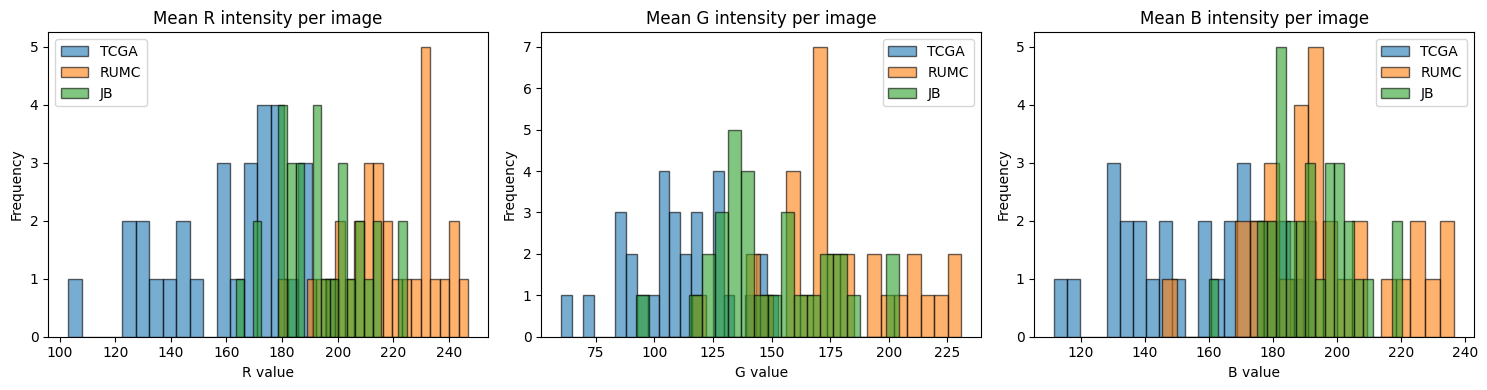


Interpretation:
If distributions overlap significantly -> stain variation is minimal -> skip stain norm
If distributions are clearly separated -> stain variation is high -> consider stain norm


In [ ]:
if len(df_color) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, channel in zip(axes, ['R', 'G', 'B']):
        for source in df_color['source'].unique():
            vals = df_color[df_color['source'] == source][channel]
            ax.hist(vals, bins=20, alpha=0.6, label=source, edgecolor='black')
        ax.set_title(f'Mean {channel} intensity per image')
        ax.set_xlabel(f'{channel} value')
        ax.set_ylabel('Frequency')
        ax.legend()
    plt.tight_layout()
    plt.show()

    print("\nInterpretation:")
    print("If distributions overlap significantly -> stain variation is minimal -> skip stain norm")
    print("If distributions are clearly separated -> stain variation is high -> consider stain norm")


## Summary & Next Steps

**Dataset Overview:**
- Total images: _(see Step 5)_
- Total annotated cells: _(see Step 5)_
- Source breakdown: _(see Step 5)_
- Corrupted files: _(see Step 4)_

**Stain Normalization Decision:**
Based on the color distributions in Step 7:
- If clearly separated by source -> **Add stain normalization to detection pipeline**
- If largely overlapping -> **Skip stain norm, follow paper's simpler approach**

**Next:** Build the Segmentation EDA notebook to analyze tissue masks and the 7-class -> 3-class remapping.
